# 4. LISA and the idea of a global fit

**FQCP 2026 · Bayesian parameter estimation for compact binaries**

> Self-contained and designed for Google Colab. Run top to bottom; **Extension** cells may be skipped live.


## Goal

Understand why long-lived overlapping LISA sources should often be modelled jointly. Two nearby sinusoids in one channel provide a small visual analogy.

In [1]:
import os
import numpy as np
import matplotlib.pyplot as plt
from IPython.display import HTML, display
from matplotlib.animation import FuncAnimation

IN_COLAB = "COLAB_RELEASE_TAG" in os.environ
rng = np.random.default_rng(20260817)
plt.style.use("seaborn-v0_8-whitegrid")
plt.rcParams["animation.html"] = "jshtml"
print("Running in Colab:", IN_COLAB)

Running in Colab: False


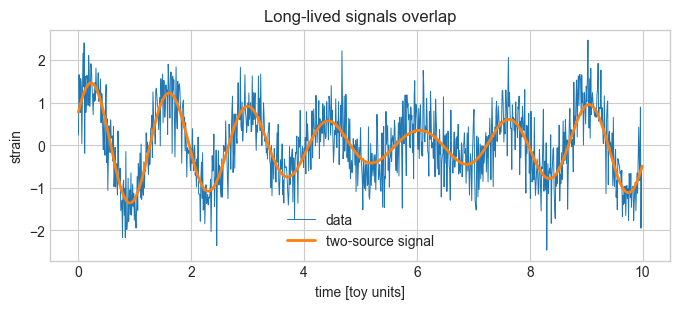

In [2]:
time=np.linspace(0,30,3000,endpoint=False)
f1,f2=.70,.76; phi1,phi2=.2,1.1; a1_true,a2_true=1.,.65; sigma=.55
def source_1(a): return a*np.sin(2*np.pi*f1*time+phi1)
def source_2(a): return a*np.sin(2*np.pi*f2*time+phi2)
signal_true=source_1(a1_true)+source_2(a2_true)
data=signal_true+rng.normal(0,sigma,time.size); show=time<10
fig,ax=plt.subplots(figsize=(8,3)); ax.plot(time[show],data[show],lw=.7,label="data")
ax.plot(time[show],signal_true[show],lw=2,label="two-source signal")
ax.set(xlabel="time [toy units]",ylabel="strain",title="Long-lived signals overlap"); ax.legend(); plt.show()

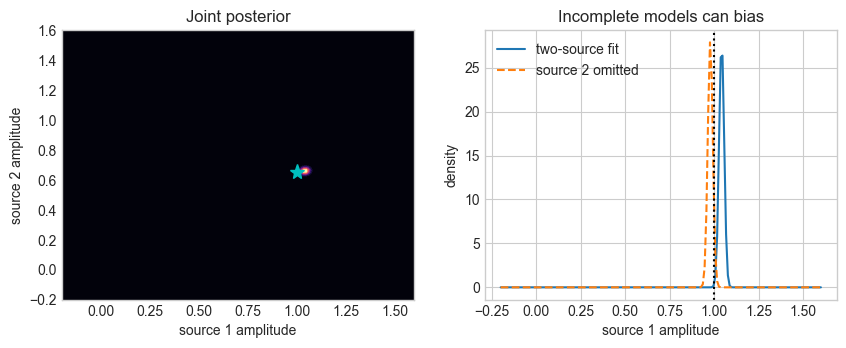

In [3]:
grid=np.linspace(-.2,1.6,180); log_joint=np.empty((grid.size,grid.size))
for i,a1 in enumerate(grid):
    for j,a2 in enumerate(grid):
        residual=data-source_1(a1)-source_2(a2)
        log_joint[i,j]=-.5*np.sum((residual/sigma)**2)
joint=np.exp(log_joint-log_joint.max()); joint/=joint.sum()
marginal=joint.sum(axis=1); marginal/=np.trapezoid(marginal,grid)
wrong_log=np.array([-.5*np.sum(((data-source_1(a))/sigma)**2) for a in grid])
wrong=np.exp(wrong_log-wrong_log.max()); wrong/=np.trapezoid(wrong,grid)
fig,axes=plt.subplots(1,2,figsize=(10,3.5))
axes[0].contourf(grid,grid,joint.T,levels=25,cmap="magma"); axes[0].plot(a1_true,a2_true,"c*",ms=11)
axes[0].set(xlabel="source 1 amplitude",ylabel="source 2 amplitude",title="Joint posterior")
axes[1].plot(grid,marginal,label="two-source fit"); axes[1].plot(grid,wrong,ls="--",label="source 2 omitted")
axes[1].axvline(a1_true,color="k",ls=":"); axes[1].set(xlabel="source 1 amplitude",ylabel="density",title="Incomplete models can bias"); axes[1].legend(); plt.show()

## Animation: subtraction is only as good as the model

Watch the residual as the assumed source-2 amplitude approaches its true value.

In [4]:
frames=np.linspace(0,a2_true,30); fig,ax=plt.subplots(figsize=(8,3.2)); line,=ax.plot([],[],lw=.8)
ax.axhline(0,color="k",lw=.7); ax.set(xlim=(0,10),ylim=(-2.5,2.5),xlabel="time",ylabel="data - model")
def update_subtraction(frame):
    residual=data-source_1(a1_true)-source_2(frames[frame])
    line.set_data(time[show],residual[show]); ax.set_title(f"assumed source-2 amplitude = {frames[frame]:.2f}")
    return (line,)
animation=FuncAnimation(fig,update_subtraction,frames=len(frames),interval=120)
plt.close(fig); display(HTML(animation.to_jshtml()))

## Check and boundary

<details><summary>Why is this a miniature global fit?</summary>

Both source amplitudes are inferred simultaneously against one dataset. A realistic LISA fit may combine source classes, noise, backgrounds, multiple TDI channels, response models, and an unknown number of Galactic binaries.

</details>

Continue with LISA Analysis Tools Workshop Tutorial 1, Tutorial 6, and its mini-global-fit challenge.